In [34]:
# ==========================================================
# COMMON SETUP
# ==========================================================

!pip install scikit-learn seaborn matplotlib requests joblib

import os, requests, zipfile, random, cv2
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import *

# -------------------------------
# DOWNLOAD GITHUB REPO
# -------------------------------
url = "https://github.com/Nayanapmku/facial_recognition/archive/refs/heads/main.zip"

r = requests.get(url, stream=True)
with open("repo.zip","wb") as f:
    for chunk in r.iter_content(1024):
        f.write(chunk)

with zipfile.ZipFile("repo.zip","r") as zip_ref:
    zip_ref.extractall("github_repo")

repo_root = [os.path.join("github_repo",x) for x in os.listdir("github_repo")][0]

# -------------------------------
# FIND FILES
# -------------------------------
embedding_file = None
preprocess_folder = None

for root, dirs, files in os.walk(repo_root):
    if "face_embeddings.npz" in files:
        embedding_file = os.path.join(root,"face_embeddings.npz")
    if "preprocess_aligned" in dirs:
        preprocess_folder = os.path.join(root,"preprocess_aligned")

# -------------------------------
# LOAD DATA
# -------------------------------
data = np.load(embedding_file, allow_pickle=True)

X_train = data["train_embeddings"]
y_train = data["train_labels"]
X_val   = data["val_embeddings"]
y_val   = data["val_labels"]
X_test  = data["test_embeddings"]
y_test  = data["test_labels"]
test_paths = data["test_paths"]

# -------------------------------
# ENCODE + SCALE
# -------------------------------
le = LabelEncoder()
y_train_enc = le.fit_transform(y_train)
y_val_enc   = le.transform(y_val)
y_test_enc  = le.transform(y_test)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val   = scaler.transform(X_val)
X_test  = scaler.transform(X_test)

# -------------------------------
# IMAGE HELPER
# -------------------------------
def show_predictions(model, name):
    print(f"\n🔍 {name} - 3 RANDOM TEST PREDICTIONS\n")

    for i in random.sample(range(len(X_test)), 3):

        sample = X_test[i].reshape(1,-1)
        pred = model.predict(sample)[0]
        pred_label = le.inverse_transform([pred])[0]

        if hasattr(model, "predict_proba"):
            conf = model.predict_proba(sample).max()
        else:
            conf = 1.0

        true_label = y_test[i]
        img_path = test_paths[i]

        if not os.path.exists(img_path):
            fname = os.path.basename(img_path)
            for root, dirs, files in os.walk(preprocess_folder):
                if fname in files:
                    img_path = os.path.join(root,fname)
                    break

        img = cv2.imread(img_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        print("True:", true_label, "| Pred:", pred_label, "| Conf:", round(conf,3))

        plt.imshow(img)
        plt.title(f"{name}\nTrue:{true_label} | Pred:{pred_label}")
        plt.axis("off")
        plt.show()

k = 1 Val Acc: 1.0
k = 3 Val Acc: 1.0
k = 5 Val Acc: 1.0
k = 7 Val Acc: 1.0

Best KNN Val Accuracy: 1.0

KNN TEST RESULTS
Accuracy: 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         2
           1       1.00      1.00      1.00         2
           2       1.00      1.00      1.00         3
           3       1.00      1.00      1.00         3

    accuracy                           1.00        10
   macro avg       1.00      1.00      1.00        10
weighted avg       1.00      1.00      1.00        10



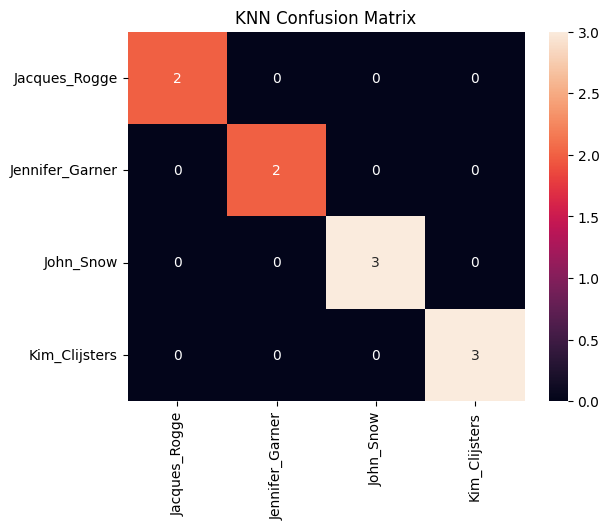


🔍 KNN - 3 RANDOM TEST PREDICTIONS

True: Kim_Clijsters | Pred: Kim_Clijsters | Conf: 1.0


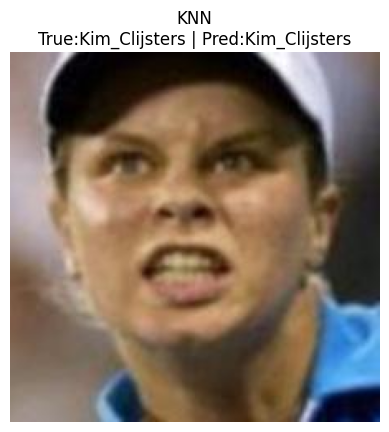

True: John_Snow | Pred: John_Snow | Conf: 1.0


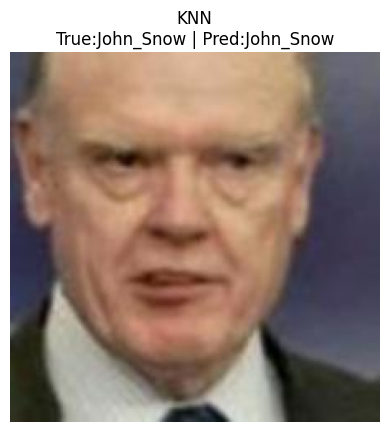

True: John_Snow | Pred: John_Snow | Conf: 1.0


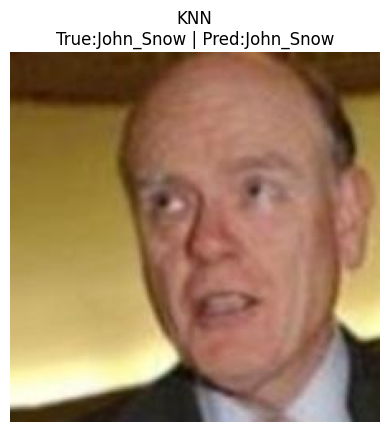

In [35]:
# FACE RECOGNITION MODEL 1 - KNN
from sklearn.neighbors import KNeighborsClassifier

best_acc = 0
best_model = None

for k in [1,3,5,7]:

    model = KNeighborsClassifier(n_neighbors=k)
    model.fit(X_train, y_train_enc)

    val_pred = model.predict(X_val)
    acc = accuracy_score(y_val_enc, val_pred)

    print("k =", k, "Val Acc:", acc)

    if acc > best_acc:
        best_acc = acc
        best_model = model

print("\nBest KNN Val Accuracy:", best_acc)

# TEST
knn_pred = best_model.predict(X_test)

print("\nKNN TEST RESULTS")
print("Accuracy:", accuracy_score(y_test_enc,knn_pred))
print(classification_report(y_test_enc,knn_pred))

sns.heatmap(confusion_matrix(y_test_enc,knn_pred), annot=True,
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.title("KNN Confusion Matrix")
plt.show()

show_predictions(best_model, "KNN")

C = 0.01 Val Acc: 1.0
C = 0.1 Val Acc: 1.0
C = 1 Val Acc: 1.0
C = 10 Val Acc: 1.0

Best Logistic Val Accuracy: 1.0

LOGISTIC TEST RESULTS
Accuracy: 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         2
           1       1.00      1.00      1.00         2
           2       1.00      1.00      1.00         3
           3       1.00      1.00      1.00         3

    accuracy                           1.00        10
   macro avg       1.00      1.00      1.00        10
weighted avg       1.00      1.00      1.00        10



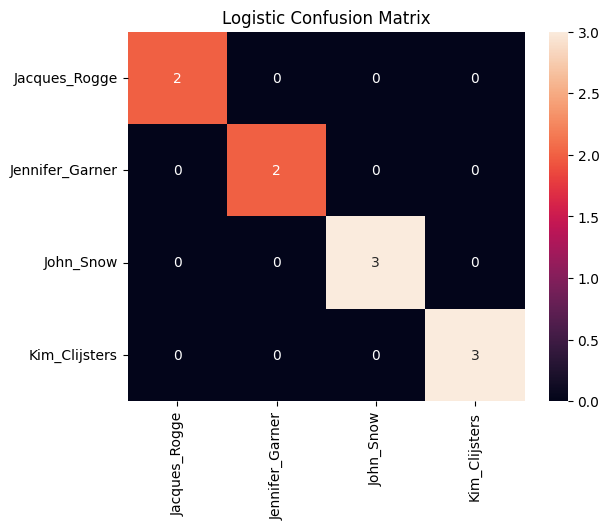


🔍 Logistic - 3 RANDOM TEST PREDICTIONS

True: Jacques_Rogge | Pred: Jacques_Rogge | Conf: 0.646


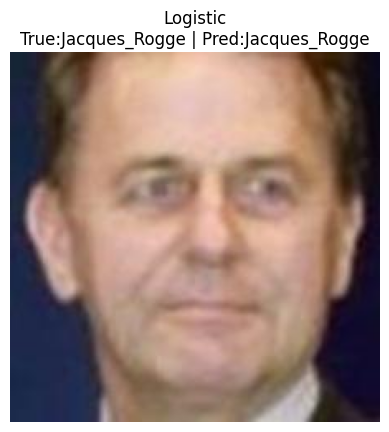

True: Kim_Clijsters | Pred: Kim_Clijsters | Conf: 0.732


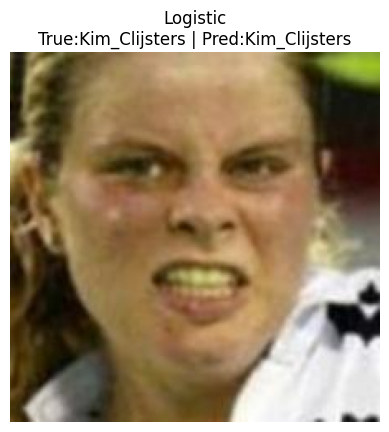

True: John_Snow | Pred: John_Snow | Conf: 0.815


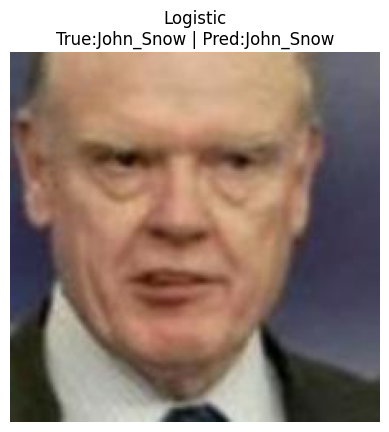

In [36]:
# FACE RECOGNITION MODEL 2 - LOGISTIC REGRESSION
from sklearn.linear_model import LogisticRegression

best_acc = 0
best_model = None

for C in [0.01,0.1,1,10]:

    model = LogisticRegression(C=C, max_iter=5000)
    model.fit(X_train, y_train_enc)

    val_pred = model.predict(X_val)
    acc = accuracy_score(y_val_enc, val_pred)

    print("C =", C, "Val Acc:", acc)

    if acc > best_acc:
        best_acc = acc
        best_model = model

print("\nBest Logistic Val Accuracy:", best_acc)

# TEST
log_pred = best_model.predict(X_test)

print("\nLOGISTIC TEST RESULTS")
print("Accuracy:", accuracy_score(y_test_enc,log_pred))
print(classification_report(y_test_enc,log_pred))

sns.heatmap(confusion_matrix(y_test_enc,log_pred), annot=True,
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.title("Logistic Confusion Matrix")
plt.show()

show_predictions(best_model, "Logistic")

linear 0.1 Val Acc: 1.0
linear 1 Val Acc: 1.0
linear 10 Val Acc: 1.0
rbf 0.1 Val Acc: 0.2727272727272727
rbf 1 Val Acc: 1.0
rbf 10 Val Acc: 1.0

Best SVM Val Accuracy: 1.0

SVM TEST RESULTS
Accuracy: 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         2
           1       1.00      1.00      1.00         2
           2       1.00      1.00      1.00         3
           3       1.00      1.00      1.00         3

    accuracy                           1.00        10
   macro avg       1.00      1.00      1.00        10
weighted avg       1.00      1.00      1.00        10



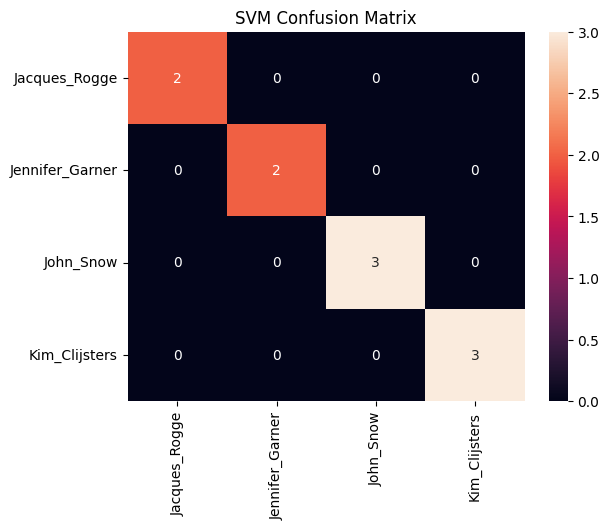


🔍 SVM - 3 RANDOM TEST PREDICTIONS

True: John_Snow | Pred: John_Snow | Conf: 0.835


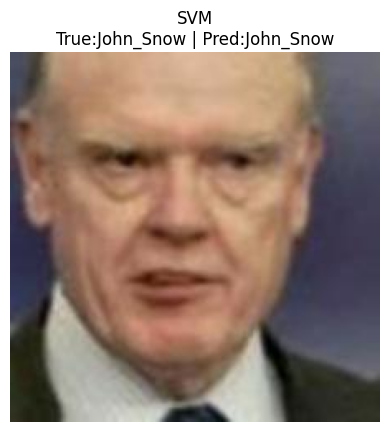

True: Jennifer_Garner | Pred: Jennifer_Garner | Conf: 0.738


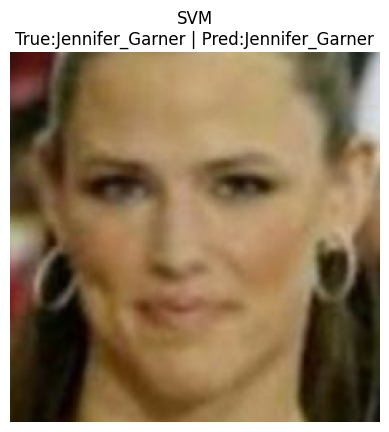

True: Jacques_Rogge | Pred: Jacques_Rogge | Conf: 0.744


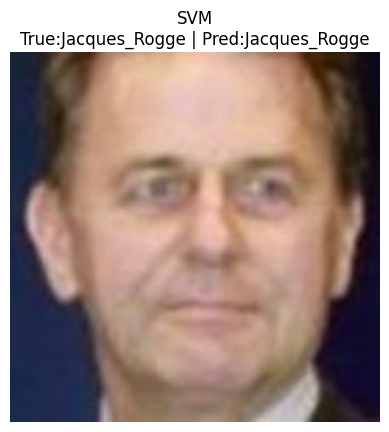

In [37]:
# FACE RECOGNITION MODEL 3 - SUPPORT VECTOR MACHINE (SVM)
from sklearn.svm import SVC

best_acc = 0
best_model = None

for kernel in ['linear','rbf']:
    for C in [0.1,1,10]:

        model = SVC(kernel=kernel, C=C, probability=True)
        model.fit(X_train, y_train_enc)

        val_pred = model.predict(X_val)
        acc = accuracy_score(y_val_enc, val_pred)

        print(kernel, C, "Val Acc:", acc)

        if acc > best_acc:
            best_acc = acc
            best_model = model

print("\nBest SVM Val Accuracy:", best_acc)

# TEST
svm_pred = best_model.predict(X_test)

print("\nSVM TEST RESULTS")
print("Accuracy:", accuracy_score(y_test_enc,svm_pred))
print(classification_report(y_test_enc,svm_pred))

# Confusion Matrix
sns.heatmap(confusion_matrix(y_test_enc,svm_pred), annot=True,
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.title("SVM Confusion Matrix")
plt.show()

show_predictions(best_model, "SVM")

Cosine Val Accuracy: 1.0

COSINE TEST RESULTS
Accuracy: 1.0
                 precision    recall  f1-score   support

  Jacques_Rogge       1.00      1.00      1.00         2
Jennifer_Garner       1.00      1.00      1.00         2
      John_Snow       1.00      1.00      1.00         3
  Kim_Clijsters       1.00      1.00      1.00         3

       accuracy                           1.00        10
      macro avg       1.00      1.00      1.00        10
   weighted avg       1.00      1.00      1.00        10



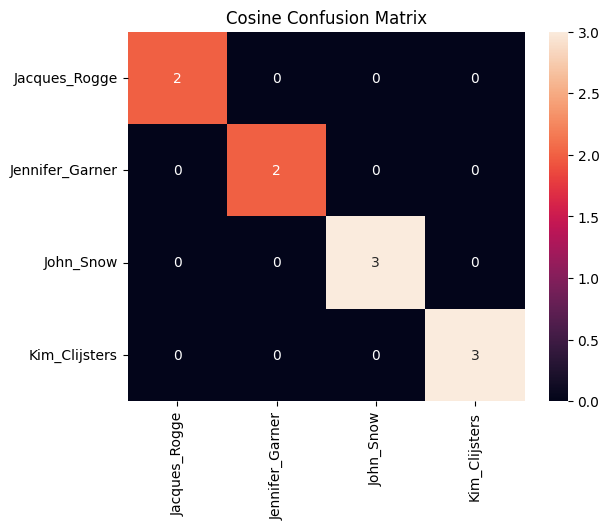


🔍 Cosine - 3 RANDOM TEST PREDICTIONS

True: Kim_Clijsters | Pred: Kim_Clijsters | Sim: 0.822


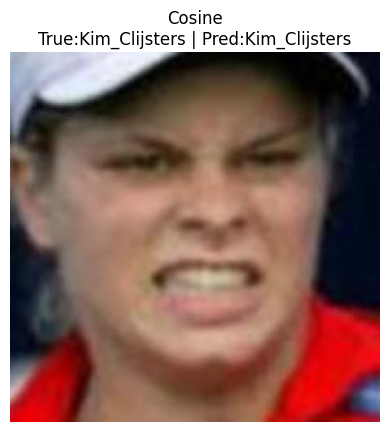

True: Jacques_Rogge | Pred: Jacques_Rogge | Sim: 0.688


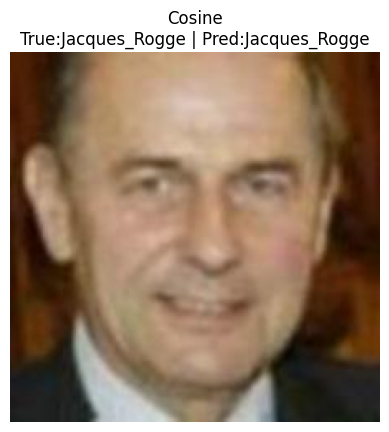

True: John_Snow | Pred: John_Snow | Sim: 0.628


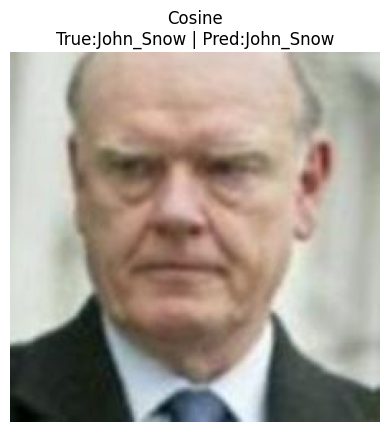

In [38]:
# FACE RECOGNITION MODEL 4 - COSINE SIMILARITY
from sklearn.metrics.pairwise import cosine_similarity

def predict_cosine(test_emb):
    sims = cosine_similarity([test_emb], X_train)[0]
    idx = np.argmax(sims)
    return y_train[idx], sims[idx]

# VALIDATION
val_preds = []
for emb in X_val:
    label,_ = predict_cosine(emb)
    val_preds.append(label)

print("Cosine Val Accuracy:", accuracy_score(y_val_enc, le.transform(val_preds)))


# TEST
test_preds = []
for emb in X_test:
    label,_ = predict_cosine(emb)
    test_preds.append(label)

print("\nCOSINE TEST RESULTS")
print("Accuracy:", accuracy_score(y_test,test_preds))
print(classification_report(y_test,test_preds))

sns.heatmap(confusion_matrix(y_test,test_preds,labels=le.classes_),
            annot=True, xticklabels=le.classes_, yticklabels=le.classes_)
plt.title("Cosine Confusion Matrix")
plt.show()

# VISUALIZE 3
print("\n🔍 Cosine - 3 RANDOM TEST PREDICTIONS\n")

for i in random.sample(range(len(X_test)), 3):

    pred_label, conf = predict_cosine(X_test[i])
    true_label = y_test[i]

    img_path = test_paths[i]

    if not os.path.exists(img_path):
        fname = os.path.basename(img_path)
        for root, dirs, files in os.walk(preprocess_folder):
            if fname in files:
                img_path = os.path.join(root,fname)
                break

    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    print("True:", true_label, "| Pred:", pred_label, "| Sim:", round(float(conf),3))

    plt.imshow(img)
    plt.title(f"Cosine\nTrue:{true_label} | Pred:{pred_label}")
    plt.axis("off")
    plt.show()